Importing a library needed

In [49]:
import sqlite3

import pandas as pd
from sklearn import set_config
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import joblib

# Data Fetching & Cleaning

Connecting a database

In [35]:
conn = sqlite3.connect("../superstore.sqlite")

Combining tables (Denormalizing the table)

In [36]:
df = pd.read_sql_query(
    """
    SELECT
        oi.row_id,
        oi.order_key,
        oi.sales,
        oi.quantity,
        oi.discount,
        oi.profit,
        oi.shipping_cost,
        o.order_date,
        o.ship_date,
        o.ship_mode,
        o.order_priority,
        dc.customer_id,
        dc.segment,
        dp.category,
        dp.sub_category,
        dp.product_name
    FROM order_items oi 
    JOIN dim_products dp ON oi.product_id = dp.product_id
    JOIN orders o ON oi.order_key = o.order_key 
    JOIN dim_customers dc ON o.customer_id = dc.customer_id
    """,
    conn,
)
df.head()

,row_id,order_key,sales,quantity,discount,profit,shipping_cost,order_date,ship_date,ship_mode,order_priority,customer_id,segment,category,sub_category,product_name
0,1,MX-2014-143658_SC-205753,13.0,3,0.0,4.56,1.033,2014-10-02 00:00:00,2014-10-06 00:00:00,Standard Class,Medium,SC-205753,Consumer,Office Supplies,Labels,"Hon File Folder Labels, Adjustable"
1,2,MX-2012-155047_KW-165703,252.0,8,0.0,90.72,13.449,2012-10-15 00:00:00,2012-10-20 00:00:00,Standard Class,Medium,KW-165703,Consumer,Furniture,Furnishings,"Tenex Clock, Durable"
2,3,MX-2012-155047_KW-165703,193.0,2,0.0,54.08,9.627,2012-10-15 00:00:00,2012-10-20 00:00:00,Standard Class,Medium,KW-165703,Consumer,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Mobile"
3,4,MX-2012-155047_KW-165703,35.0,4,0.0,4.96,1.371,2012-10-15 00:00:00,2012-10-20 00:00:00,Standard Class,Medium,KW-165703,Consumer,Office Supplies,Binders,"Cardinal Binder, Clear"
4,5,MX-2012-155047_KW-165703,72.0,2,0.0,11.44,3.787,2012-10-15 00:00:00,2012-10-20 00:00:00,Standard Class,Medium,KW-165703,Consumer,Office Supplies,Art,"Sanford Canvas, Water Color"


Cleaning up data

In [37]:
# Deduplicate
dupes = df.duplicated().sum()
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)

# Text Normalization
cols_to_be_text_normalized = [
    "ship_mode",
    "order_priority",
    "segment",
    "category",
    "sub_category",
    "product_name",
]

for col in cols_to_be_text_normalized:
    df[col] = df[col].astype(str).str.lower().str.strip()

# Date
cols_to_be_date_formatted = [
    "order_date",
    "ship_date",
]

for col in cols_to_be_date_formatted:
    df[col] = pd.to_datetime(df[col])

df.head()


,row_id,order_key,sales,quantity,discount,profit,shipping_cost,order_date,ship_date,ship_mode,order_priority,customer_id,segment,category,sub_category,product_name
0,1,MX-2014-143658_SC-205753,13.0,3,0.0,4.56,1.033,2014-10-02,2014-10-06,standard class,medium,SC-205753,consumer,office supplies,labels,"hon file folder labels, adjustable"
1,2,MX-2012-155047_KW-165703,252.0,8,0.0,90.72,13.449,2012-10-15,2012-10-20,standard class,medium,KW-165703,consumer,furniture,furnishings,"tenex clock, durable"
2,3,MX-2012-155047_KW-165703,193.0,2,0.0,54.08,9.627,2012-10-15,2012-10-20,standard class,medium,KW-165703,consumer,furniture,bookcases,"ikea 3-shelf cabinet, mobile"
3,4,MX-2012-155047_KW-165703,35.0,4,0.0,4.96,1.371,2012-10-15,2012-10-20,standard class,medium,KW-165703,consumer,office supplies,binders,"cardinal binder, clear"
4,5,MX-2012-155047_KW-165703,72.0,2,0.0,11.44,3.787,2012-10-15,2012-10-20,standard class,medium,KW-165703,consumer,office supplies,art,"sanford canvas, water color"


# Classification

In [ ]:
# Add new column to use as a feature
df["is_profitable"] = (df["profit"] > 0).astype(int)

Split the feature and target

In [39]:
feature_cols = [
    "discount",
    "shipping_cost",
    "ship_mode",
    "segment",
    "category",
    "sub_category",
]

X = df[feature_cols]
y = df["is_profitable"]

Split the data to training and testing data

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=131205, test_size=0.2, stratify=y)

Preprocess the data

In [41]:
numeric_features = ["discount", "shipping_cost"]
categorical_features = ["ship_mode", "segment", "category", "sub_category"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])

Train the model

In [ ]:
# Create a pipeline
set_config(display="diagram")

model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", random_state=131205))
])

model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['discount',
                                                   'shipping_cost']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['ship_mode', 'segment',
                                                   'category',
                                                   'sub_category'])])),
                ('model',
                 LogisticRegression(class_weight='balanced',
                                    random_state=131205))])

In [ ]:
# Train the classification model
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Loss (0)", "Profit (1)"]))

              precision    recall  f1-score   support

    Loss (0)       0.80      0.85      0.83      2642
  Profit (1)       0.95      0.93      0.94      7616

    accuracy                           0.91     10258
   macro avg       0.87      0.89      0.88     10258
weighted avg       0.91      0.91      0.91     10258



# Clustering

Using RFM and K-Means Clustering

In [44]:
# Getting snapshot date so that the frequency isn't far off
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("customer_id")
    .agg(
        recency=("order_date", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_key", "nunique"),
        monetary=("sales", "sum"),
    )
    .reset_index()
)

rfm.head()

,customer_id,recency,frequency,monetary
0,AA-103151,9,5,1445.0
1,AA-103152,14,7,6105.0
2,AA-103153,695,2,633.0
3,AA-103154,185,5,5565.0
4,AA-103751,7,4,2407.0


In [45]:
# The data need to standardize in scaling beforehand
features = ["recency", "frequency", "monetary"]

X_rfm = rfm[features]
X_scaled = StandardScaler().fit_transform(X_rfm)

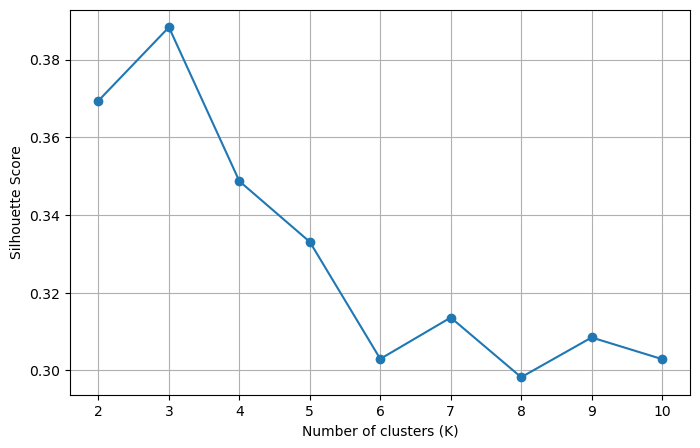

In [ ]:
# Get the optimized K using Elbow Method
inertia_score = []
silhouette_scores = []
k_range = range(2, 11)


for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=131205, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Visualize the score
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

# Since K = 3 is the peak, K = 3 is chosen

In [ ]:
# Create a cluster model

kmeans = KMeans(n_clusters=3, random_state=131205, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

profile = (
    rfm.groupby("cluster")[["recency", "frequency", "monetary"]]
    .agg(["mean", "median", "count"])
    .round(1)
)

profile

recency              frequency              monetary              
           mean median count      mean median count     mean  median count
cluster                                                                   
0         734.5  667.0   661       2.1    2.0   661    768.5   420.0   661
1          95.1   62.0  1573       8.3    8.0  1573   5201.4  4698.0  1573
2         142.4  108.0  2639       4.2    4.0  2639   1497.9  1304.0  2639

# Freezing the model

In [48]:
# Classification Model
joblib.dump(model, "profit_classification.pkl")

# Clustering Model
joblib.dump(kmeans, "user_clustering.pkl")
joblib.dump(StandardScaler().fit(X_rfm), "rfm_scale.pkl")

['rfm_scale.pkl']